In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

data = "Wholesale_customers_data.csv"
df = pd.read_csv(data)
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [30]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [31]:
df.columns = df.columns.str.strip()
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
x = df[features].values
# x.head()

In [32]:
# масштабирование данных
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

k = 2 and score = [0.5472146913441881]
k = 3 and score = [0.5472146913441881, 0.5482872649700601]


<function matplotlib.pyplot.show(close=None, block=None)>

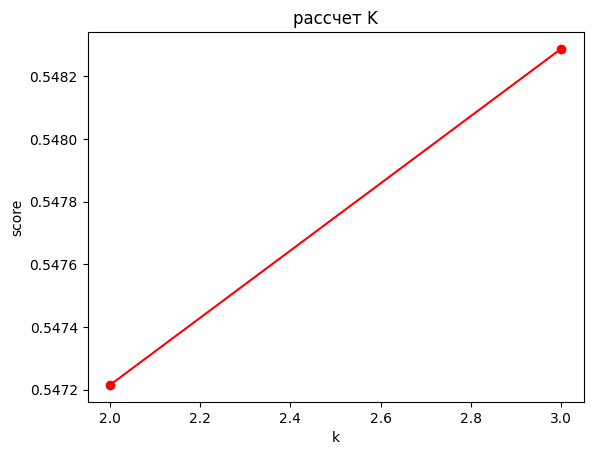

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_score = []
for k in range(2, 4):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(x_scaler)
    score = silhouette_score(x_scaler, kmeans.labels_)
    sil_score.append(score)
    print(f"k = {k} and score = {sil_score}")
    
plt.plot(range(2, 4), sil_score, 'ro-')
plt.xlabel('k'); plt.ylabel('score');plt.title('рассчет K')
plt.show

In [43]:
k_means = KMeans(n_clusters=3, n_init=10, random_state=42)
df["Cluster"] = k_means.fit_predict(x_scaler)
print(df["Cluster"].sort_index())

0      1
1      1
2      1
3      1
4      1
      ..
435    1
436    1
437    0
438    1
439    1
Name: Cluster, Length: 440, dtype: int32


In [ ]:
# lables = k_means.labels_
# plt.Figure(figsize=(10, 13))
# plt.scatter(
    
#     c = lables,
#     cmap="veridis"
#     s=40
    
# )

In [49]:
df['Cluster'] = k_means.labels_
stats = (
    df.groupby('Cluster')[features]
.mean()
)
print(stats)



                Fresh          Milk  ...  Detergents_Paper    Delicassen
Cluster                              ...                                
0        10440.933333  19386.422222  ...      13327.800000   2374.200000
1        12062.913486   4115.099237  ...       1696.170483   1299.114504
2        34782.000000  30367.000000  ...        755.500000  26776.000000

[3 rows x 6 columns]


In [50]:
cluster_shares = (
    stats
    .div(stats.sum(axis=1), axis=0)
    .round(2)
)

print(cluster_shares)

         Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                            
0         0.14  0.25     0.38    0.03              0.17        0.03
1         0.44  0.15     0.20    0.11              0.06        0.05
2         0.22  0.19     0.11    0.31              0.00        0.17


In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaler)


<function matplotlib.pyplot.show(close=None, block=None)>

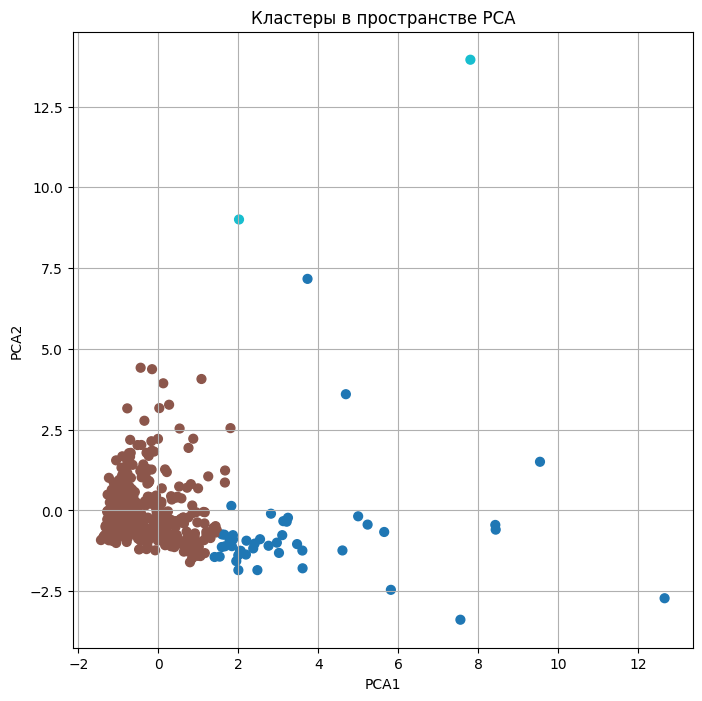

In [59]:
plt.figure(figsize=(8, 8))
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c = df['Cluster'],
    cmap='tab10',
    s=40
)
plt.xlabel('PCA1'); plt.ylabel('PCA2');plt.title('Кластеры в пространстве PCA')
plt.grid(True)
plt.show